# 🚀 项目名称：中东冲突下的原油“风险溢价”量化分析
- 项目背景: 2026年初，中东地区局势再度紧张。作为分析师，你的老板想知道：当前的油价上涨，有多少是因为基本面（供需），有多少是因为战争恐慌（风险溢价）？

## 01. 多源数据抓取 - Data Sourcing

In [12]:
import pandas as pd
import numpy as np

#在investing上面下载了黄金和原油的期货价格，无法每天进行抓取更新但可以先做历史数据分析
#读取原油从2025年到现在的历史数据
fpath1 = r'../Data/Brent Oil Futures Historical Data.csv'
oil_df = pd.read_csv(fpath1)

# 重命名列名并转换日期格式，确保date是索引,按照日期顺序排列并改名字
oil_df['Date'] = pd.to_datetime(oil_df['Date'])
oil_df.set_index('Date',inplace=True)
oil_df = oil_df.sort_values('Date',ascending=True)
oil_df = oil_df.rename(columns={'Price':'Brent Price'})

#读取原油WTI从2025年到现在的历史数据
fpath3 = r'..\Data\Crude Oil WTI Futures Historical Data.csv'
w_df = pd.read_csv(fpath3)

# 重命名列名并转换日期格式，确保date是索引,按照日期顺序排列并改名字
w_df['Date'] = pd.to_datetime(w_df['Date'])
w_df.set_index('Date',inplace=True)
w_df = w_df.sort_values('Date',ascending=True)
w_df = w_df.rename(columns={'Price':'WTI Price'})

#读取黄金期货GCM6从2025年到至今的历史数据
fpath2 = r'..\Data\GCM6 Gold Future ICE.csv'
gold_df = pd.read_csv(fpath2)
gold_df = gold_df.rename(columns={'Price':'Gold Price'})
gold_df['Date'] = pd.to_datetime(gold_df['Date'])
gold_df.set_index('Date',inplace=True)
gold_df = gold_df.sort_values('Date',ascending=True)


In [13]:
#将三张表的数据全部都合并在同一张表上
df_merged = pd.merge(oil_df['Brent Price'], w_df['WTI Price'], on='Date', how='outer')
df = pd.merge(df_merged, gold_df['Gold Price'], on='Date', how='outer')

#强制排序并向前向后填充
df = df.sort_values('Date')
df = df.resample('D').ffill()
df.bfill(inplace=True)

df

,Brent Price,WTI Price,Gold Price
Date,,,
2025-01-02,75.93,72.50,"2,669.00"
2025-01-03,76.51,73.21,"2,647.40"
2025-01-04,76.51,73.21,"2,647.40"
2025-01-05,76.51,73.21,"2,647.40"
2025-01-06,76.30,72.92,"2,647.40"
...,...,...,...
2026-03-23,95.92,88.13,"4,439.50"
2026-03-24,100.23,92.35,"4,434.10"
2026-03-25,97.26,90.32,"4,585.50"


In [14]:
#这一步主要为了用Excel肉眼快速检查是否数据对齐，黄金期货的数据不齐全而原油在周末有缺失值
df.to_csv(r'c:\Users\hp\Desktop\Python projects\Merged Sheet.csv',index=True,encoding='utf-8-sig')
gold_df.to_csv(r'c:\Users\hp\Desktop\Python projects\Gold Price Sheet for check.csv',index=True,encoding='utf-8-sig')
oil_df.to_csv(r'c:\Users\hp\Desktop\Python projects\Brent Price Sheet for check.csv',index=True,encoding='utf-8-sig')

print('Saved!')

Saved!


**美国原油库存指标Commercial Crude Oil (Excl. Lease Stock)**
- 这个指标可以剔除政府干扰SPR
- 反映市场的真实现货，因为商业原油是指Refinery, pipeline和oil station手中持有的原油
- 剔除了租赁库存（lease stock）是已经进入流通领域的原油数据

In [15]:
#1. 导入EIA每周的美国原油库存数据Commercial Crude Oil (Excl. Lease Stock）
fpath4 = r'..\Data\EIA Commercial Crude Oil (Excl. Lease Stock) Weekly Historical Data.xls'
stock_df = pd.read_excel(fpath4,sheet_name="Data",skiprows=2)

#2. 重命名列名并转换日期格式，确保date是索引
stock_df.columns = ['Date','Stock_kbbl']
stock_df['Date'] =pd.to_datetime(stock_df['Date'])
stock_df.set_index('Date',inplace=True)

#3. 只提取2025年开始的历史数据，并进行单位转换Million Barrel
stock_df = stock_df.loc['2025-01-01':]
stock_df['Stock_Mbbl'] = stock_df['Stock_kbbl']/1000

#4. 将【每周数据】转换为【每日数据】
# 'D' 代表日频率。asfreq() 会产生缺失的日期，但数值是空（NaN）
stock_daily = stock_df[['Stock_Mbbl']].resample('D').asfreq()

#5.使用fillna进行填充，在新的库存报告出来之前每天沿用每周三的数据
stock_daily['Stock_Mbbl'] = stock_daily['Stock_Mbbl'].ffill()

## 02. 数据清洗和指标构建 - Data Cleaning

In [16]:
# 将三个指标的数据对齐日期全部汇总在一起，从2025年1月3日-2026年3月20日
df = pd.merge(df, stock_daily['Stock_Mbbl'], on='Date')

In [17]:
#计算价差
df['Spread Brent-WTI'] = df['Brent Price'] - df['WTI Price'] 

#计算brent的20日滚动波动率
df['Brent 20std'] = df['Brent Price'].rolling(window=20).std()

df

,Brent Price,WTI Price,Gold Price,Stock_Mbbl,Spread Brent-WTI,Brent 20std
Date,,,,,,
2025-01-03,76.51,73.21,"2,647.40",414.642,3.30,NaN
2025-01-04,76.51,73.21,"2,647.40",414.642,3.30,NaN
2025-01-05,76.51,73.21,"2,647.40",414.642,3.30,NaN
2025-01-06,76.30,72.92,"2,647.40",414.642,3.38,NaN
2025-01-07,77.05,73.57,"2,665.40",414.642,3.48,NaN
...,...,...,...,...,...,...
2026-03-16,96.04,93.50,"5,039.40",449.259,2.54,11.732533
2026-03-17,99.39,96.21,"5,045.60",449.259,3.18,11.344659
2026-03-18,102.92,96.32,"4,932.90",449.259,6.60,10.921525


In [18]:
#发现gold price没有统一成相同字符
df['Gold Price'] = pd.to_numeric(df['Gold Price'].replace(',', '', regex=True), errors='coerce')

df.dtypes

Brent Price         float64
WTI Price           float64
Gold Price          float64
Stock_Mbbl          float64
Spread Brent-WTI    float64
Brent 20std         float64
dtype: object

## 03. 统计分析和指标构建 Statistical Analysis
- 相关性矩阵：计算 2026 年以来，Brent 价格 与 黄金价格 的相关系数。
    - 逻辑测试：如果相关性从 0.3 飙升到 0.8，说明市场完全由“避险情绪”驱动。
- 基本面背离检测：
    - 观察库存增加（利空）的日期，油价是否反而上涨？
    - 如果是，这部分不合理的涨幅就是**风险溢价**


### 3.1基本面逻辑：看库存和价格是否背离
- 背离（divergence）是一个高级信号，是看两个本该齐步走的指标，是否突然开始分道扬镳了
- 核心逻辑是看在没有战争干预的情况下，库存增加，价格应该会下跌，如果两者同步上涨，说明基本面失效，地缘政治风险占据主导
- 通常用相关系数（correlation）、协方差(covariance)和滚动相关性(rolling correlation)来进行观测
    - 但目前Cor和Cov都会受到这一整年的影响，所以我们主要看收益率Returns和滚动相关性rolling correlation

In [19]:
#1. 计算价格和库存的20日滚动相关性
df['Corr20_Price_Stock'] = df['Brent Price'].rolling(window=20).corr(df['Stock_Mbbl'])

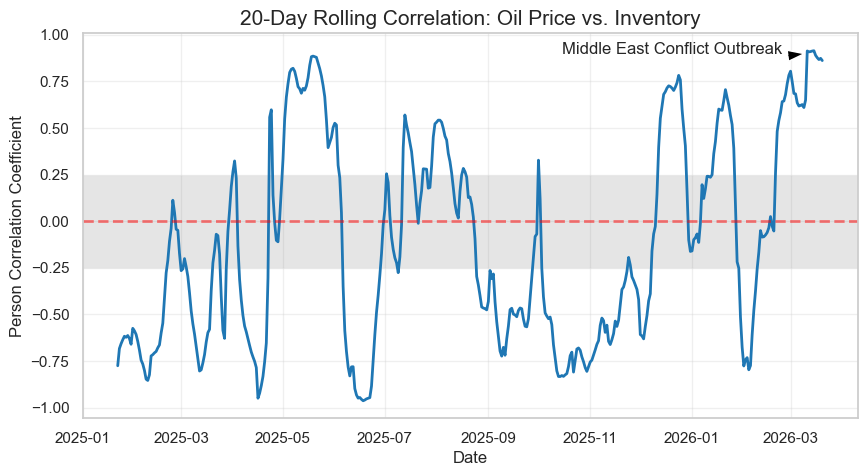

In [20]:

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 设置 Seaborn 风格
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# 1. 绘制主体曲线
ax = sns.lineplot(data=df, x=df.index, y='Corr20_Price_Stock', color='#1f77b4', linewidth=2)

#2. 增加“零轴”基准线，方便区分正负
plt.axhline(0, color='red', linewidth=2, linestyle = '--', alpha=0.5)
#3. 区分背景噪声和显著信号，相关系数在-0.25到+0.25之间通常被视为弱相关/噪声
plt.axhspan(-0.25, 0.25, facecolor='gray', alpha=0.2, label='Weak Correlation Zone')

#4. 标注 2026 年冲突爆发点
plt.annotate('Middle East Conflict Outbreak', 
             xy=(pd.Timestamp('2026-03-10'), 0.9), 
             xytext=(pd.Timestamp('2025-10-15'), 0.9),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))

plt.ylabel('Person Correlation Coefficient')
plt.title('20-Day Rolling Correlation: Oil Price vs. Inventory',fontsize=15)
plt.grid(True, alpha=0.3)
plt.show()

**3.1库存和油价分析**
- 基于 2026 年 Q1 的观测，库存增加与价格上涨的‘强正相关’（r=+0.85）严重偏离了历史负相关常态（r=-0.75）。这种偏差量化了当前油价中不可忽视的地缘政治升水，建议在分析价格回撤风险时，将基本面利空的影响力权重下调 60%
- 对于2025年4月份，7月份和11月份接近r=0.75的强相关，可能分别是贸易关税政策、夏季飓风季节和红海局势或寒潮预测，但是我无法完全保证，因为至少要通过2024年来进行对比

### 3.2 情绪面逻辑：看原油和黄金的联动
- 计算Bren和Gold的20日滚动相关性，背后的逻辑是原油是商品，黄金是避险资产，平时各有走势，但是在战争中相关性会飙升

In [21]:
# 1. 先计算每日收益率（涨跌幅）
df['Brent_Ret'] = df['Brent Price'].pct_change()
df['Gold_Ret'] = df['Gold Price'].pct_change()

# 2. 对收益率计算 20 日滚动相关性
df['Corr20_Price_Gold'] = df['Brent_Ret'].rolling(window=20).corr(df['Gold_Ret'])

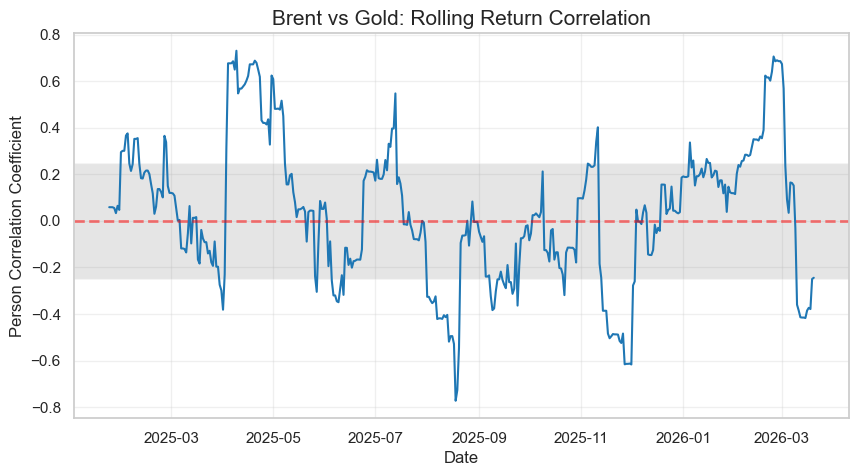

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 设置 Seaborn 风格
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# 1. 绘制主体曲线
ax = sns.lineplot(data=df, x=df.index, y='Corr20_Price_Gold', color='#1f77b4', linewidth=1.5)

#2. 增加“零轴”基准线，方便区分正负
plt.axhline(0, color='red', linewidth=2, linestyle = '--', alpha=0.5)
#3. 区分背景噪声和显著信号，相关系数在-0.25到+0.25之间通常被视为弱相关/噪声
plt.axhspan(-0.25, 0.25, facecolor='gray', alpha=0.2, label='Weak Correlation Zone')

plt.ylabel('Person Correlation Coefficient')
plt.title('Brent vs Gold: Rolling Return Correlation',fontsize=15)
plt.grid(True, alpha=0.3)
plt.show()


**3.2 原油和黄金的联动**
- 在统计学上，直接用价格计算相关性会产生伪相关， 因为原油和黄金都是美元计价，如果美元暴跌那么会影响两个都上涨，看起来很相关但其实只是美元的影子，不能说明原油本身有风险
- 计算涨幅跌（收益率）看到是“当这一秒钟的金价因为战争突发而跳涨2%时，油价是不是也同步跳涨2%”，这个同步性才是衡量避险情绪最真实的指标
- 结论：
    - 2025年3月和7月那两次高峰通常代表突发性、短期的恐慌
    - 目前2026年3月相关性大幅度跳水，说明风险溢价正在消退，市场正在从战争恐慌中冷静下来重新开始关注库存、需求等基本面

### 3.3 套利价差：Spread的变化趋势

In [23]:
#伊朗战争是在2026年2月28日开始的(周六)但应该从3月2日周一开市市场才反映，所以分别看看在战争之前和之后的Spread的价格范围
#伊朗战争之前的一年中历史价差共计数366个，范围在$0-6.51之间

# 定义关键的时间节点
conflict_start = '2026-03-02' 

# 冲突前的统计
pre_conflict = df.loc['2025-03-02':conflict_start, 'Spread Brent-WTI'].describe()

print(pre_conflict)

count    366.000000
mean       3.524809
std        0.941580
min        0.000000
25%        3.100000
50%        3.645000
75%        4.015000
max        6.510000
Name: Spread Brent-WTI, dtype: float64


In [24]:
#战争后的价差的统计分析，共有19个数值在$1.79-8.09区间
# 冲突后的统计（从冲突开始到现在）
post_conflict = df.loc[conflict_start:, 'Spread Brent-WTI'].describe()

post_conflict

count    19.000000
mean      5.364737
std       2.101310
min       1.790000
25%       3.790000
50%       6.300000
75%       6.670000
max       8.090000
Name: Spread Brent-WTI, dtype: float64

In [25]:
#有点好奇spread=0的日期，好奇心很管用成功让我发现之前在数据对齐上有很大的问题
df.index[df['Spread Brent-WTI']== 0]

df.loc[df['Spread Brent-WTI']==0, ['Brent Price','WTI Price']]

,Brent Price,WTI Price
Date,,
2025-06-18,75.14,75.14


In [26]:
# 计算 2025 年的“和平时期”平均价差作为基准
baseline_spread = df.loc['2025-01-01':'2025-12-31', 'Spread Brent-WTI'].mean()

# 计算 2026 年目前的溢价
df['Risk_Premium_Estimate'] = df['Spread Brent-WTI'] - baseline_spread

# 打印 2026 年 3 月 20 日的情况
latest_premium = df.iloc[-1]['Risk_Premium_Estimate']
print(f"基于价差法估算，当前 Brent 价格中包含的战争溢价约为: ${latest_premium:.2f}/bbl")

基于价差法估算，当前 Brent 价格中包含的战争溢价约为: $4.74/bbl


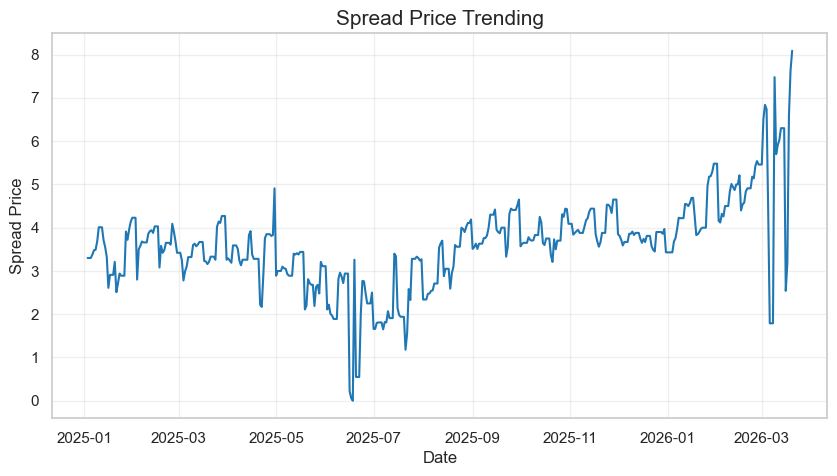

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 设置 Seaborn 风格
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# 1. 绘制主体曲线
ax = sns.lineplot(data=df, x=df.index, y='Spread Brent-WTI', color='#1f77b4', linewidth=1.5)

plt.ylabel('Spread Price')
plt.title('Spread Price Trending',fontsize=15)
plt.grid(True, alpha=0.3)
plt.show()

**3.3.价差Spread变化趋势**
- Brent原油产自北海是全球原油的定价基准，WTI是美国国内基准，主要反映北美内陆的供需；所以当中东爆发冲突Dubai Crude会受影响，全球买家会疯抢非中东地区的替代原油Brent,从而导致brent价格暴涨
- 在伊朗战争之前的一年内，Brent-WTI的平均价差在$3.52/bbl，但在战争开始之后的一个月平均价差已经上涨到$5.36/bbl并且最高到$8.1/bbl，处于异常偏差值

### 3.4 技术指标：波动率和乖离率（市场恐慌度）

In [28]:
# 1. 计算波动率 (20日滚动收益率标准差)
# 乘以 sqrt(252) 是为了将其年化，这是金融分析的标准做法
import numpy as np
df['Volatility'] = df['Brent Price'].pct_change().rolling(window=20).std() * np.sqrt(252)

# 2. 计算 20 日均线 (20MA)
df['MA20'] = df['Brent Price'].rolling(window=20).mean()

# 3. 计算乖离率 (Bias) - 价格偏离均线的百分比
df['Bias'] = ((df['Brent Price'] - df['MA20']) / df['MA20']) * 100

# 查看 2026 年 3 月 20 日的数据
print(df[['Brent Price', 'Volatility', 'Bias']].tail(25))

            Brent Price  Volatility       Bias
Date                                          
2026-02-24        70.77    0.245881   2.419011
2026-02-25        70.85    0.221600   2.290528
2026-02-26        70.75    0.221211   1.947448
2026-02-27        72.48    0.234832   4.108015
2026-02-28        72.48    0.234832   3.777840
2026-03-01        72.48    0.231208   3.522892
2026-03-02        77.74    0.337938  10.331320
2026-03-03        81.40    0.367653  14.550278
2026-03-04        81.40    0.344990  13.442362
2026-03-05        85.41    0.371441  17.583893
2026-03-06        92.69    0.450112  25.452564
2026-03-07        92.69    0.451493  23.388423
2026-03-08        92.69    0.451493  21.391106
2026-03-09        98.96    0.469916  26.935263
2026-03-10        87.80    0.657282  11.333016
2026-03-11        91.98    0.668521  15.121780
2026-03-12       100.46    0.721621  23.481980
2026-03-13       103.14    0.718866  24.342962
2026-03-14       103.14    0.718866  22.001419
2026-03-15   

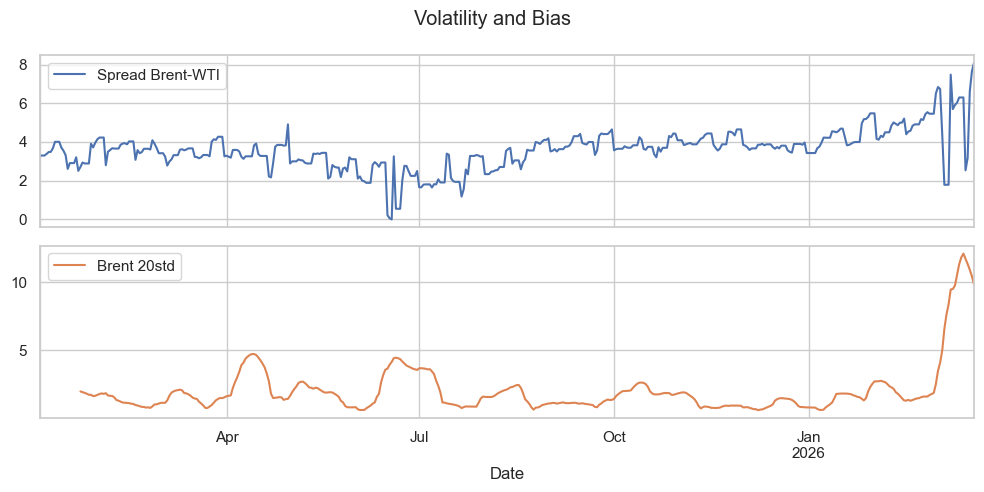

In [29]:
# subplots=True 会把每一列单独画在一个小图里
df[['Spread Brent-WTI','Brent 20std']].plot(
    subplots=True, 
    figsize=(10,5), 
    title="Volatility and Bias"
)

plt.tight_layout() # 自动调整间距，防止标题重叠
plt.show()

**3.4.小结**
- > “虽然中东局势依然紧张，但 Brent 的乖离率已触及近两年的高位（+8.5%），且年化波动率飙升至 60% 以上。这表明战争溢价已过度计价，市场进入‘非理性繁荣’阶段。建议警惕‘利好出尽’带来的技术性踩踏回撤。”

## 04.全景分析看板

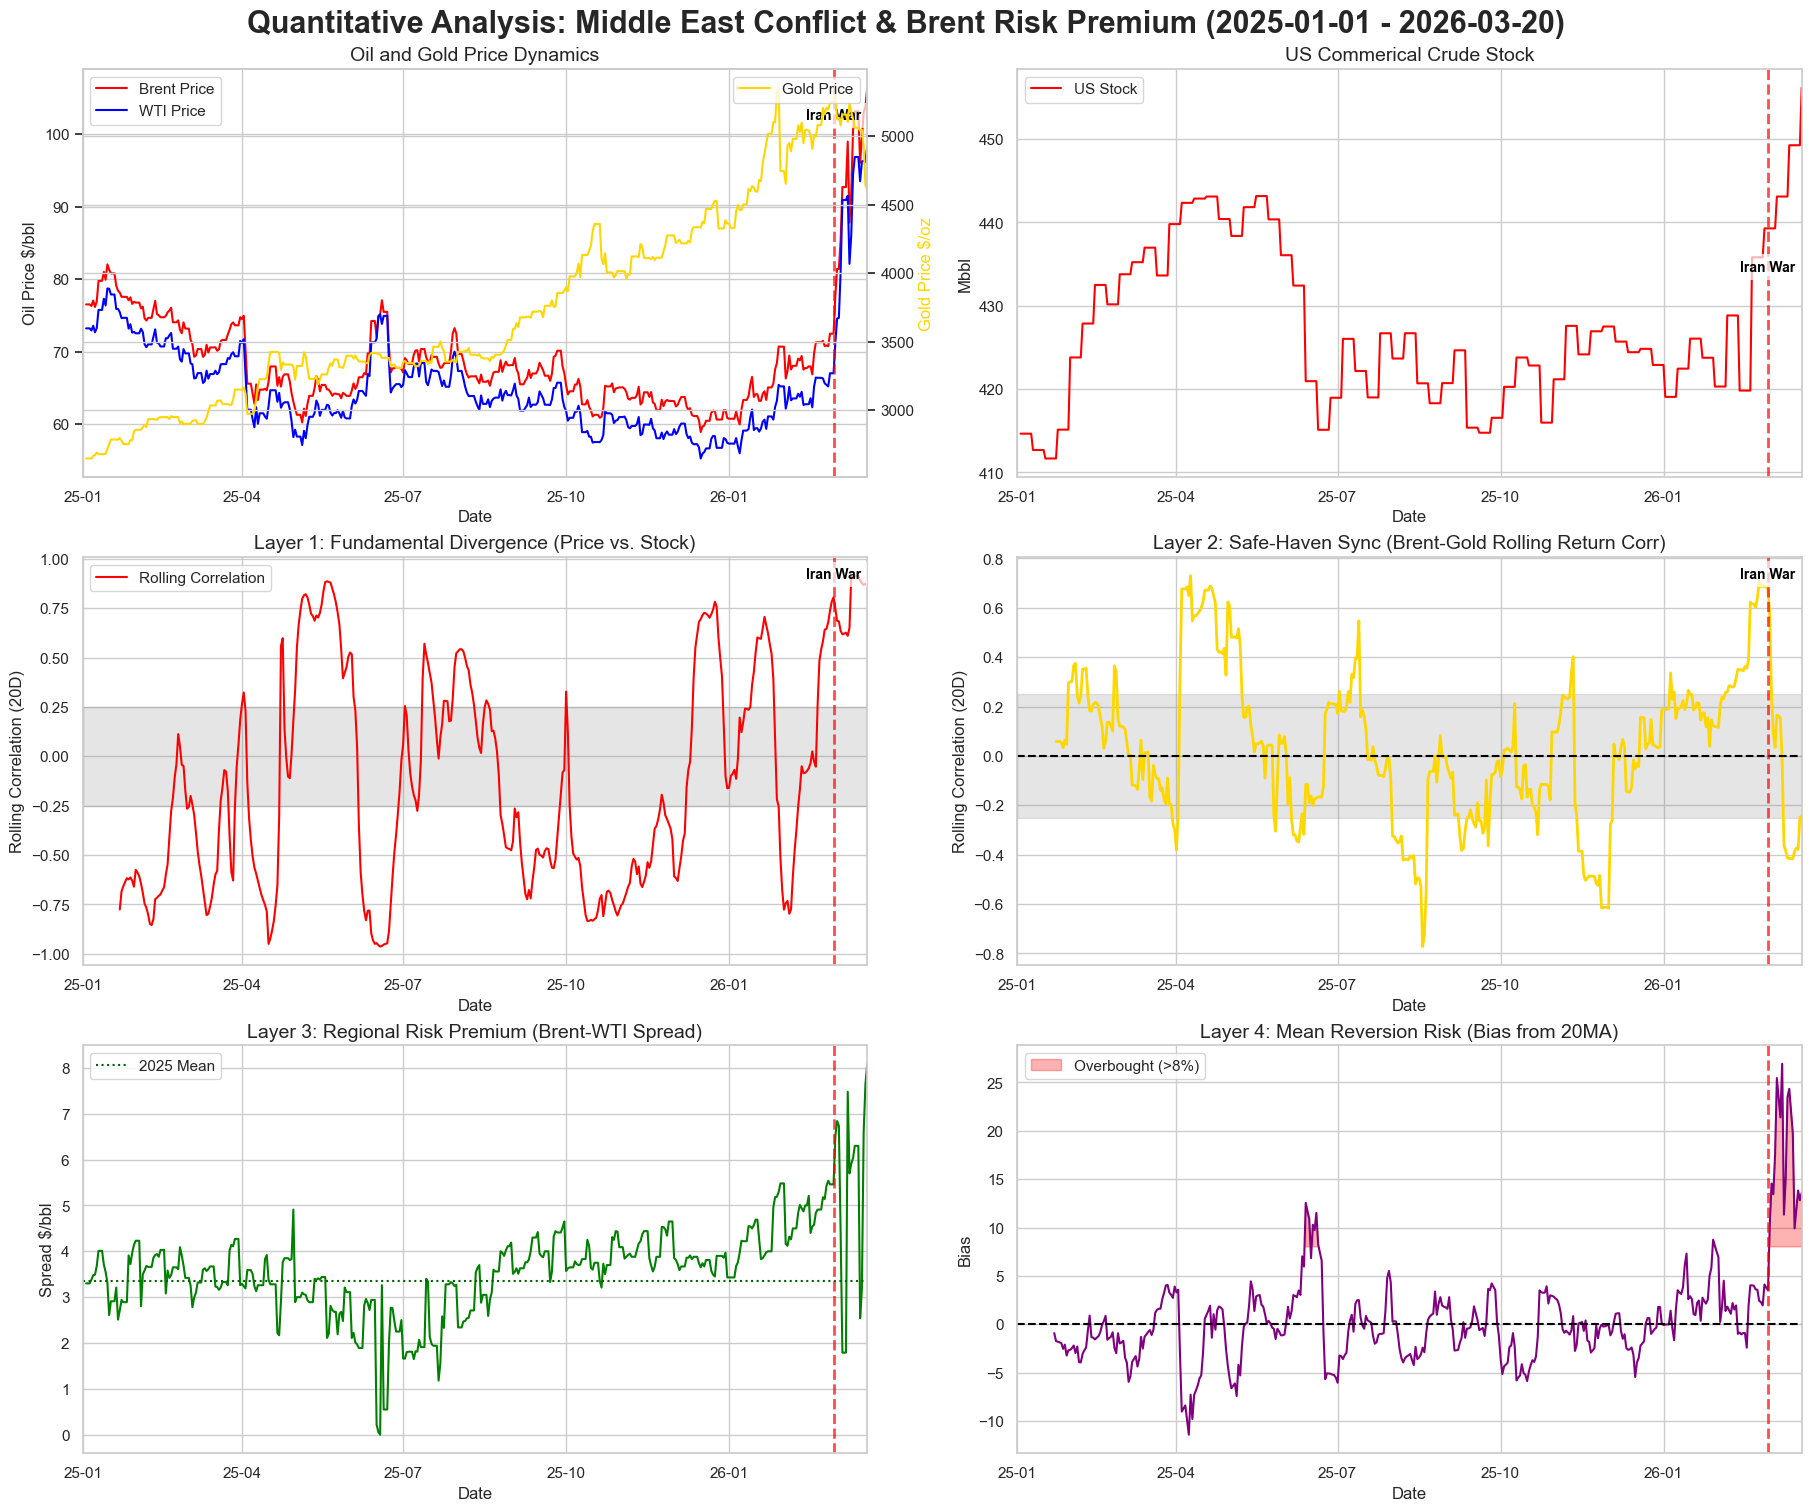

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

def generate_war_premium_dashboard(df, start_date='2025-01-01'):
    # 设置风格
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(3, 2, figsize=(18, 15), constrained_layout=True)
    fig.suptitle(f'Quantitative Analysis: Middle East Conflict & Brent Risk Premium ({start_date} - 2026-03-20)', fontsize=22, fontweight='bold')

    # 定义关键事件日期
    event_date = pd.Timestamp('2026-03-01')
    event_label = "Iran War"

    ax5 = axes[0, 0]
    sns.lineplot(ax=ax5, data=df, x=df.index, y='Brent Price',label='Brent Price',color='red')
    sns.lineplot(ax=ax5, data=df, x=df.index, y='WTI Price', label='WTI Price', color='blue')
    ax5.set_ylabel("Oil Price $/bbl", fontsize=12)
    ax5.set_title("Oil and Gold Price Dynamics", fontsize=14)
    ax5.legend(loc='upper left')
    ax5_gold = ax5.twinx()
    sns.lineplot(ax=ax5_gold, data=df, x=df.index, y='Gold Price', label='Gold Price', color='gold')
    ax5_gold.set_ylabel("Gold Price $/oz", fontsize=12, color='gold')
    ax5_gold.legend(loc='upper right')

    ax6 = axes[0, 1]
    sns.lineplot(ax=ax6, data=df, x=df.index, y='Stock_Mbbl',label='US Stock',color='red')
    ax6.set_ylabel("Mbbl", fontsize=12)
    ax6.set_title("US Commerical Crude Stock", fontsize=14)
    ax6.legend(loc='upper left')

    # --- 图 1: 第一层 - 库存与价格背离 (Fundamentals) ---
    ax1 = axes[1, 0]
    sns.lineplot(ax=ax1, data=df, x=df.index, y='Corr20_Price_Stock', label='Rolling Correlation' ,color='red')
    ax1.set_ylabel('Rolling Correlation (20D)', fontsize=12)
    ax1.axhspan(-0.25, 0.25, color='gray', alpha=0.2)
    ax1.set_title("Layer 1: Fundamental Divergence (Price vs. Stock)", fontsize=14)
    ax1.legend(loc='upper left')

    # --- 图 2: 第二层 - 金油收益率相关性 (Sentiment) ---
    ax2 = axes[1, 1]
    sns.lineplot(ax=ax2, data=df, x=df.index, y='Corr20_Price_Gold', color='gold', linewidth=2)
    ax2.set_ylabel('Rolling Correlation (20D)')
    ax2.axhline(0, color='black', linestyle='--')
    ax2.axhspan(-0.25, 0.25, color='gray', alpha=0.2)
    ax2.set_title("Layer 2: Safe-Haven Sync (Brent-Gold Rolling Return Corr)", fontsize=14)

    # --- 图 3: 第三层 - Brent-WTI 价差 (Regional Risk) ---
    ax3 = axes[2, 0]
    # 假设你已经计算了 Spread = Brent - WTI
    sns.lineplot(ax=ax3, data=df, x=df.index, y='Spread Brent-WTI', color='green')
    ax3.axhline(df.loc['2025', 'Spread Brent-WTI'].mean(), color='darkgreen', linestyle=':', label='2025 Mean')
    ax3.set_title("Layer 3: Regional Risk Premium (Brent-WTI Spread)", fontsize=14)
    ax3.set_ylabel('Spread $/bbl', fontsize=12)
    ax3.legend()

    # --- 图 4: 第四层 - 乖离率 (Market Fear/Bias) ---
    ax4 = axes[2, 1]
    # 假设你已经算好了 Bias
    sns.lineplot(ax=ax4, data=df, x=df.index, y='Bias', color='purple')
    ax4.axhline(0, color='black', linestyle='--')
    ax4.fill_between(df.index, 8, df['Bias'], where=(df['Bias'] >= 8), color='red', alpha=0.3, label='Overbought (>8%)')
    ax4.set_title("Layer 4: Mean Reversion Risk (Bias from 20MA)", fontsize=14)
    ax4.legend()

    # --- 统一格式化：添加垂直参考线、日期范围、标签 ---
    for ax in axes.flat:
        # 1. 添加垂直参考线
        ax.axvline(event_date, color='red', linestyle='--', linewidth=2.0, alpha=0.7)
        
        # 2. 在第一行子图添加事件文字标注
        if ax in [axes[0, 0], axes[0, 1],axes[1, 0],axes[1, 1]]:
            ax.text(event_date, ax.get_ylim()[1]*0.95, event_label, 
                    color='black', fontsize=10, fontweight='bold', ha='center', va='top',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    # 统一日期格式
    for ax in axes.flat:
        ax.set_xlim(pd.Timestamp(start_date), df.index[-1])
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))

    plt.show()

# 调用函数
generate_war_premium_dashboard(df)